In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

In [8]:
RESULTS_DIR = Path("results/g_scan")

In [9]:
L = 30
N = 20
chi_list = [64, 128]

In [10]:
data = {}
for chi in chi_list:
    data[chi] = {}
    for path in sorted(RESULTS_DIR.glob(f"ni_L{L}_N{N}_chi{chi}_g*.npz")):
        g = float(path.stem.split("_g")[-1])
        d = np.load(path)
        data[chi][g] = {
            "ni"    : d["ni"],
            "tr_TB" : d["tr_TB"],
            "t_grid": d["t_grid"],
            "W"     : float(d["W"]),
        }

In [ ]:
g_values = sorted(data[64].keys())

def plot_g(g):
    vals = data[64][g]
    plt.figure(figsize=(10, 3.5))
    plt.plot(vals["t_grid"], np.sum(vals["ni"], axis=0))
    plt.ylabel(r"$\sum_j n_j(t)$")
    plt.xlabel("time")
    plt.title(f"g = {g:.4f}")
    plt.tight_layout()
    plt.show()

slider = widgets.SelectionSlider(
    options=g_values,
    description="g",
    continuous_update=False,
)

widgets.interact(plot_g, g=slider)

interactive(children=(SelectionSlider(continuous_update=False, description='g', options=(1.0, 1.051282, 1.1025…

<function __main__.plot_g(g)>

In [12]:
def plot_chi_g(chi, g):
    vals = data[chi][g]
    plt.figure(figsize=(10, 3.5))
    plt.plot(vals["t_grid"], np.sum(vals["ni"], axis=0))
    plt.ylabel(r"$\sum_j n_j(t)$")
    plt.xlabel("time")
    plt.title(f"chi={chi}, g={g:.4f}")
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_chi_g,
    chi=widgets.Dropdown(options=chi_list, description="chi"),
    g=widgets.SelectionSlider(options=sorted(data[chi_list[0]].keys()), description="g"),
)

interactive(children=(Dropdown(description='chi', options=(64, 128), value=64), SelectionSlider(description='g…

<function __main__.plot_chi_g(chi, g)>

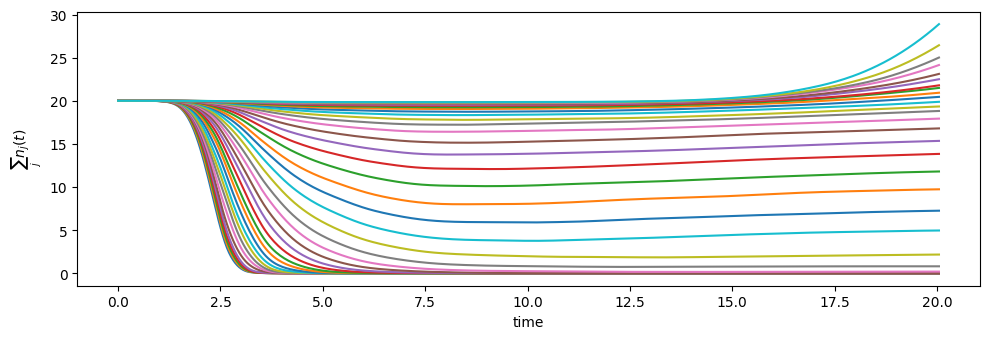

In [14]:
plt.figure(figsize=(10, 3.5))
for g, vals in data[64].items():
    # print(g, vals["ni"])
    plt.plot(vals["t_grid"], np.sum(vals["ni"], axis=0), label=f"g={g}")
# plt.hlines(N, color="gray", linestyle=":", linewidth=1, label=f"N={N}")
plt.ylabel(r"$\sum_j n_j(t)$")
plt.xlabel("time")
# plt.legend()

plt.tight_layout()
plt.show()